In [75]:
import ast
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    average_precision_score, r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [76]:
def _make_sparse_weights(dim, sparsity, rng, min_weight_ratio=0.0):
    w = np.zeros(dim, dtype=np.float32)
    n_active = max(1, int(sparsity * dim))
    active_idx = rng.choice(dim, size=n_active, replace=False)
    
    # Sample raw magnitudes
    magnitudes = rng.uniform(low=0.5, high=1.0, size=n_active)
    
    # Enforce minimum ratio relative to the maximum
    max_mag = magnitudes.max()
    magnitudes = np.maximum(magnitudes, min_weight_ratio * max_mag)
    
    signs = rng.choice([-1.0, 1.0], size=n_active)
    w[active_idx] = (magnitudes * signs).astype(np.float32)
    return w


_make_sparse_weights(dim=10, sparsity=0.3, rng=np.random.default_rng(10), min_weight_ratio=0.5)


array([ 0.        ,  0.        ,  0.57464105,  0.        ,  0.        ,
        0.        ,  0.5679598 ,  0.        , -0.7564023 ,  0.        ],
      dtype=float32)

## Utility helpers

In [77]:
def load_tensor(path: Path):
    assert path.exists(), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def calculate_auc(true_val, pred_val):
    """Compute AUC, flip direction if < 0.5."""
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
    return auc


## Config and path helpers

In [78]:
def read_config_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path
    with log_path.open("r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)


def get_data_dir_name_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path
    with log_path.open("r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                return Path(line.split("data_dir:", 1)[1].strip()).name
    raise ValueError(f"Could not find data_dir in {log_path}")


def infer_data_path(experiment_path: Path):
    """Resolve absolute path to the saved dataset directory."""
    data_dir_name = get_data_dir_name_from_log(experiment_path)
    candidate = Path("datasets") / "multilabel_synthetic" / data_dir_name
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f"Dataset not found at {candidate}")


def get_multilabel_config(experiment_path: Path):
    """Return (num_concepts, num_residuals, num_hid_tasks, num_obs_tasks, hid_dim, obs_dim)."""
    cfg = read_config_from_log(experiment_path)
    d = cfg["data"]
    return (
        d["num_concepts"],
        d["num_residuals"],
        d.get("num_hid_tasks", 3),
        d.get("num_obs_tasks", 1),
        d["hid_dim"],
        d["obs_dim"],
    )


def print_data_info(experiment_path: Path):
    data_path = infer_data_path(experiment_path)
    info = data_path / "info.txt"
    if info.exists():
        print(info.read_text())


## Data loading

In [79]:
def load_split(experiment_path: Path, data_path: Path, split: str,
               num_concepts: int, num_residuals: int):
    """
    Load one split worth of model outputs + dataset tensors.

    Model outputs (from experiment_path/<split>/):
        c_res_mu.pt                        — Gaussian mean of [concept, residual] logits
        concepts_residuals_pred_probs_mean — mean sigmoid probs over MC samples
        concepts_residuals_pred_probs_std  — std of sigmoid probs over MC samples
        concepts_residuals_sample_mean     — mean of hard Bernoulli samples

    Dataset tensors (from data_path/<split>/):
        x, concepts, residuals, y (multilabel),
        eta_concepts, eta_residuals,
        concept_signal, residual_signal,
        s_hid, s_obs,
        w_hid, w_obs, Sigma,
        hid_task_idx, obs_task_idx
    """
    model_split = experiment_path / split
    data_split  = data_path      / split

    if not model_split.exists():
        raise FileNotFoundError(
            f"Missing {model_split}. Run training with save_concept_and_residual_channel=True."
        )
    assert data_split.exists(), data_split

    c_res_mu    = load_tensor(model_split / "c_res_mu.pt")
    cr_probs    = load_tensor(model_split / "concepts_residuals_pred_probs_mean.pt")
    cr_probs_std= load_tensor(model_split / "concepts_residuals_pred_probs_std.pt")
    cr_sample   = load_tensor(model_split / "concepts_residuals_sample_mean.pt")

    out = {
        # ── model outputs ──────────────────────────────────────────────
        "c_mu":                  c_res_mu[:, :num_concepts],
        "res_mu":                c_res_mu[:, num_concepts:],
        "concept_probs":         cr_probs[:, :num_concepts],
        "residual_probs":        cr_probs[:, num_concepts:],
        "concept_probs_std":     cr_probs_std[:, :num_concepts],
        "residual_probs_std":    cr_probs_std[:, num_concepts:],
        "concept_sample_mean":   cr_sample[:, :num_concepts],
        "residual_sample_mean":  cr_sample[:, num_concepts:],
        # ── dataset tensors ────────────────────────────────────────────
        "x":                     load_tensor(data_split / "x.pt"),
        "concepts":              load_tensor(data_split / "concepts.pt"),
        "hidden_residuals":      load_tensor(data_split / "residuals.pt"),
        "y":                     load_tensor(data_split / "y.pt"),           # (n, K+J)
        "eta_concepts":          load_tensor(data_split / "eta_concepts.pt"),
        "eta_residuals":         load_tensor(data_split / "eta_residuals.pt"),
        "concept_signal":        load_tensor(data_split / "concept_signal.pt"),
        "hidden_residual_signal":load_tensor(data_split / "residual_signal.pt"),
        "s_hid":                 load_tensor(data_split / "s_hid.pt"),       # (n, K)
        "s_obs":                 load_tensor(data_split / "s_obs.pt"),       # (n, J)
        "w_hid":                 load_tensor(data_split / "w_hid.pt"),
        "w_obs":                 load_tensor(data_split / "w_obs.pt"),
        "hid_task_idx":          load_tensor(data_split / "hid_task_idx.pt"),
        "obs_task_idx":          load_tensor(data_split / "obs_task_idx.pt"),
    }

    # Sanity: row counts must agree
    n_model = out["res_mu"].shape[0]
    n_data  = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split}: model has {n_model} rows but data has {n_data}. "
        "Residual dump likely used a shuffled/drop_last loader."
    )
    return out


## Specify experiment

In [80]:
# EXPERIMENT_PATH = Path(
#     "experiments/scbm_residual/multilabel_synthetic/"
#     "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_sigma_x_0.5_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-25_17-46-16_95c26"
# )

EXPERIMENT_PATH = Path(
    "experiments/scbm_residual/multilabel_synthetic/"
    "hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-26_12-44-36_fd9a9"
)





In [81]:
assert EXPERIMENT_PATH.exists(), EXPERIMENT_PATH

# Resolve dataset path and config
DATA_PATH = infer_data_path(EXPERIMENT_PATH)
(num_concepts, num_residuals,
 num_hid_tasks, num_obs_tasks,
 hid_dim, obs_dim) = get_multilabel_config(EXPERIMENT_PATH)
num_tasks = num_hid_tasks + num_obs_tasks

print(f"num_concepts : {num_concepts}")
print(f"num_residuals: {num_residuals}")
print(f"num_hid_tasks: {num_hid_tasks}  (K)")
print(f"num_obs_tasks: {num_obs_tasks}  (J)")
print(f"num_tasks    : {num_tasks}  (K+J)")
print(f"hid_dim      : {hid_dim}")
print(f"obs_dim      : {obs_dim}")
print()
print_data_info(EXPERIMENT_PATH)


num_concepts : 10
num_residuals: 20
num_hid_tasks: 5  (K)
num_obs_tasks: 2  (J)
num_tasks    : 7  (K+J)
hid_dim      : 20
obs_dim      : 10

[multilabel synthetic dataset]
num_hid_tasks : 5
num_obs_tasks : 2
num_tasks/num_classes : 7
alpha : 1.0
beta : 1.0
hid_task_idx : [5, 14, 7, 2, 17]
obs_task_idx : [4, 7]
rho_cr : 0.0
rho_cc : 0.0
rho_rr : 0.0
task_sparsity_hid : 0.25
task_sparsity_obs : 0.3
sigma_x : 0.5
hid_dim : 20
obs_dim : 10
seed : 0
train / val / test : 30000 / 10000 / 10000
min_weight_ratio : 0.4
data created for model at: /cluster/home/smarcou/work/experiments_scbm/scbm_residual/multilabel_synthetic/hid_tasks_5_obs_tasks_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_multilabel_K5_J2_hid20_R20_noise0.5_200epochs_2026-06-26_12-44-36_fd9a9



## Load data splits

In [82]:
train_data = load_split(EXPERIMENT_PATH, DATA_PATH, "train",
                        num_concepts=num_concepts, num_residuals=num_residuals)
val_data   = load_split(EXPERIMENT_PATH, DATA_PATH, "val",
                        num_concepts=num_concepts, num_residuals=num_residuals)
test_data  = load_split(EXPERIMENT_PATH, DATA_PATH, "test",
                        num_concepts=num_concepts, num_residuals=num_residuals)
splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name}:")
    for key in ["x", "res_mu", "hidden_residuals", "y", "s_hid", "s_obs"]:
        print(f"  {key:28s} {tuple(data[key].shape)}")

w_hid       = train_data["w_hid"]
w_obs       = train_data["w_obs"]
hid_task_idx = train_data["hid_task_idx"]   # (K,) — which hidden concepts are task bits
obs_task_idx = train_data["obs_task_idx"]   # (J,)


train:
  x                            (30000, 100)
  res_mu                       (30000, 20)
  hidden_residuals             (30000, 20)
  y                            (30000, 7)
  s_hid                        (30000, 5)
  s_obs                        (30000, 2)
val:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)
test:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)


## Task weights and task index mapping

In [83]:
# Hidden task weights — sorted by abs magnitude
df_w_hid = pd.DataFrame({
    "hidden_concept_idx": np.arange(w_hid.shape[0]),
    "weight":             to_numpy(w_hid),
    "abs_weight":         to_numpy(w_hid.abs()),
    "is_task_bit":        [i in hid_task_idx.tolist() for i in range(w_hid.shape[0])],
})
df_w_hid = df_w_hid[df_w_hid["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

# Annotate which subtask index each hidden concept maps to
task_map = {int(idx): k for k, idx in enumerate(hid_task_idx.tolist())}
df_w_hid["hid_task_k"] = df_w_hid["hidden_concept_idx"].map(task_map)

print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

# Observed task weights
df_w_obs = pd.DataFrame({
    "observed_concept_idx": np.arange(w_obs.shape[0]),
    "weight":               to_numpy(w_obs),
    "abs_weight":           to_numpy(w_obs.abs()),
    "is_task_bit":          [i in obs_task_idx.tolist() for i in range(w_obs.shape[0])],
})
df_w_obs = df_w_obs[df_w_obs["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

obs_task_map = {int(idx): j for j, idx in enumerate(obs_task_idx.tolist())}
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(obs_task_map)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)


Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4



Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


## Model performance — test set metrics

,y_macro_auroc,y_macro_ap,y_hamming_accuracy,y_exact_match,c_accuracy,c_AUROC
0,0.877,0.885,0.793,0.355,0.719,0.79


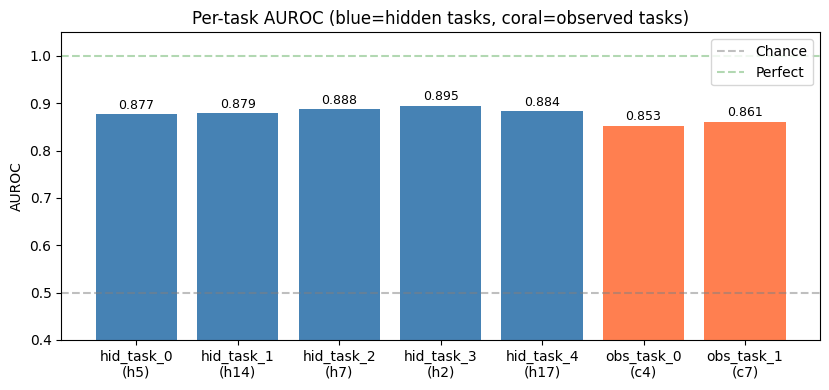

In [84]:
def parse_test_metrics_multilabel(experiment_path: Path, num_tasks: int):
    """
    Parse multilabel metrics from the last 'Test' line in log.txt.
    Returns a dict with macro_auroc, hamming_accuracy, exact_match,
    per-task auroc/ap, concept metrics.
    """
    log_path = experiment_path / "log.txt"
    test_line = None
    with log_path.open() as f:
        for line in f:
            if "Test" in line:
                test_line = line
    if test_line is None:
        raise ValueError("No 'Test' line found in log.txt")

    def grab(pattern, line, default=None):
        m = re.search(pattern, line)
        return float(m.group(1)) if m else default

    metrics = {
        "y_macro_auroc":      grab(r"y_macro_auroc:\s*([0-9.]+)", test_line),
        "y_macro_ap":         grab(r"y_macro_ap:\s*([0-9.]+)", test_line),
        "y_hamming_accuracy": grab(r"y_hamming_accuracy:\s*([0-9.]+)", test_line),
        "y_exact_match":      grab(r"y_exact_match:\s*([0-9.]+)", test_line),
        "c_accuracy":         grab(r"c_accuracy:\s*([0-9.]+)", test_line),
        "c_AUROC":            grab(r"c_AUROC:\s*([0-9.]+)", test_line),
    }
    for k in range(num_tasks):
        metrics[f"y_auroc_task_{k}"] = grab(rf"y_auroc_task_{k}:\s*([0-9.]+)", test_line)
        metrics[f"y_ap_task_{k}"]    = grab(rf"y_ap_task_{k}:\s*([0-9.]+)", test_line)
    return metrics

test_metrics = parse_test_metrics_multilabel(EXPERIMENT_PATH, num_tasks)

# Display summary
summary_df = pd.DataFrame([test_metrics])
display(summary_df[[c for c in summary_df.columns if "task" not in c]])

# Per-task AUROC bar chart
task_aurocs = [test_metrics.get(f"y_auroc_task_{k}") for k in range(num_tasks)]
task_labels = (
    [f"hid_task_{k}\n(h{hid_task_idx[k].item()})" for k in range(num_hid_tasks)]
    + [f"obs_task_{j}\n(c{obs_task_idx[j].item()})" for j in range(num_obs_tasks)]
)
colors = ["steelblue"] * num_hid_tasks + ["coral"] * num_obs_tasks

fig, ax = plt.subplots(figsize=(max(6, num_tasks * 1.2), 4))
bars = ax.bar(task_labels, task_aurocs, color=colors)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.axhline(1.0, color="green", linestyle="--", alpha=0.3, label="Perfect")
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("AUROC")
ax.set_title("Per-task AUROC (blue=hidden tasks, coral=observed tasks)")
ax.legend()
for bar, v in zip(bars, task_aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## Per-task score verification

Verify that the s_hid and s_obs tensors from the dataset match the formula.

In [85]:
config  = read_config_from_log(EXPERIMENT_PATH)
alpha   = config["data"]["alpha"]
beta    = config["data"]["beta"]

concept_signal  = test_data["concept_signal"]    # (n, obs_dim)
residual_signal = test_data["hidden_residual_signal"]  # (n, hid_dim)

shared_obs_score = concept_signal  @ w_obs   # (n,)
shared_hid_score = residual_signal @ w_hid   # (n,)

s_hid_true = test_data["s_hid"]   # (n, K)
s_obs_true  = test_data["s_obs"]  # (n, J)

print("Verifying hidden subtask scores:")
for k, idx in enumerate(hid_task_idx.tolist()):
    per_concept = residual_signal[:, idx] * float(w_hid[idx].abs())
    s_k = alpha * shared_obs_score + beta * per_concept
    diff = (s_k - s_hid_true[:, k]).abs()
    print(f"  task {k} (h{idx}): max_diff={diff.max():.2e}  mean_diff={diff.mean():.2e}")

print("\nVerifying observed subtask scores:")
for j, idx in enumerate(obs_task_idx.tolist()):
    per_concept = concept_signal[:, idx] * float(w_obs[idx].abs())
    s_j = alpha * per_concept + beta * shared_hid_score
    diff = (s_j - s_obs_true[:, j]).abs()
    print(f"  task {j} (c{idx}): max_diff={diff.max():.2e}  mean_diff={diff.mean():.2e}")


Verifying hidden subtask scores:
  task 0 (h5): max_diff=4.77e-07  mean_diff=3.48e-08
  task 1 (h14): max_diff=4.77e-07  mean_diff=3.66e-08
  task 2 (h7): max_diff=4.77e-07  mean_diff=3.54e-08
  task 3 (h2): max_diff=4.77e-07  mean_diff=3.22e-08
  task 4 (h17): max_diff=4.77e-07  mean_diff=3.21e-08

Verifying observed subtask scores:
  task 0 (c4): max_diff=4.77e-07  mean_diff=4.72e-08
  task 1 (c7): max_diff=4.77e-07  mean_diff=4.71e-08


## Distributed probe — hidden concept recovery

Logistic regression on the full `res_mu` vector to predict each hidden concept. This is the upper bound on recoverable hidden-concept information from the residual channel. Task-bit concepts (hid_task_idx) should show high AUC; non-task-bit concepts should be near chance.

Hidden concept distributed probe (task bits highlighted):


,hidden_concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid,is_task_bit,hid_task_k
5,5,0.737983,0.6708,0.660198,0.974940,0.974940,True,0.0
14,14,0.742538,0.6744,0.667416,-0.952066,0.952066,True,1.0
7,7,0.768604,0.6960,0.682937,0.891934,0.891934,True,2.0
2,2,0.731383,0.6697,0.656902,-0.609588,0.609588,True,3.0
17,17,0.680409,0.6277,0.624660,0.549488,0.549488,True,4.0
0,0,0.582192,0.5617,0.560161,0.000000,0.000000,False,NaN
12,12,0.582481,0.5610,0.558794,0.000000,0.000000,False,NaN
18,18,0.588316,0.5654,0.561895,0.000000,0.000000,False,NaN
16,16,0.567341,0.5509,0.550045,0.000000,0.000000,False,NaN
15,15,0.583686,0.5566,0.556954,0.000000,0.000000,False,NaN


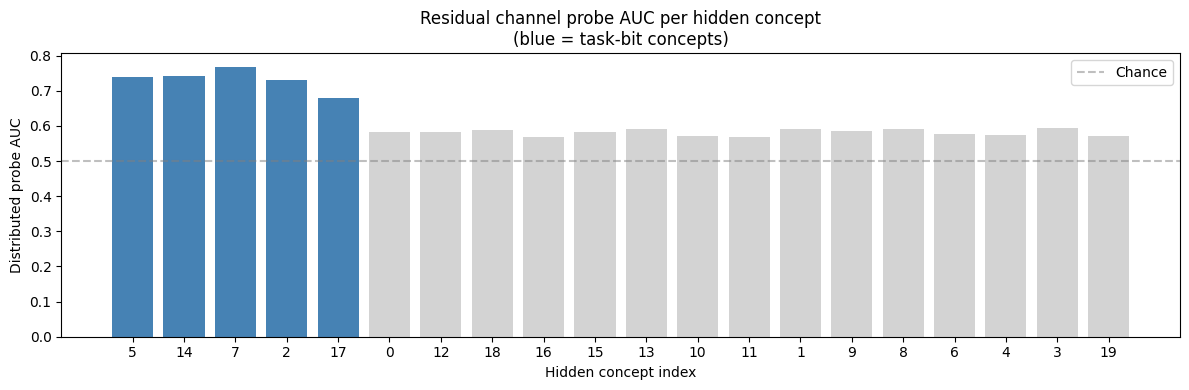

In [86]:
def probe_baseline(H_pred_train, H_true_train, H_pred_test, H_true_test,
                   column_name="hidden_concept_idx"):
    """Fit one logistic regression per column of H_true, evaluate on test set."""
    H_pred_train = to_numpy(H_pred_train).astype(float)
    H_pred_test  = to_numpy(H_pred_test).astype(float)
    H_true_train = to_numpy(H_true_train).astype(float)
    H_true_test  = to_numpy(H_true_test).astype(float)

    rows = []
    for h in range(H_true_train.shape[1]):
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
        )
        clf.fit(H_pred_train, H_true_train[:, h])
        probs = clf.predict_proba(H_pred_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        rows.append({
            column_name:           h,
            "distributed_auc":     roc_auc_score(H_true_test[:, h], probs),
            "distributed_accuracy": accuracy_score(H_true_test[:, h], preds),
            "distributed_f1":      f1_score(H_true_test[:, h], preds),
        })
    return pd.DataFrame(rows)


# Hidden concepts from res_mu
probe_hidden = probe_baseline(
    splits["train"]["res_mu"], splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"],  splits["test"]["hidden_residuals"],
)

# Annotate with task weights and task membership
probe_hidden["w_hid"]      = probe_hidden["hidden_concept_idx"].apply(lambda i: w_hid[i].item())
probe_hidden["abs_w_hid"]  = probe_hidden["w_hid"].abs()
probe_hidden["is_task_bit"]= probe_hidden["hidden_concept_idx"].isin(hid_task_idx.tolist())
probe_hidden["hid_task_k"] = probe_hidden["hidden_concept_idx"].map(task_map)
probe_hidden = probe_hidden.sort_values("abs_w_hid", ascending=False)

print("Hidden concept distributed probe (task bits highlighted):")
display(probe_hidden.head(20))

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))
colors_bar = ["steelblue" if is_tb else "lightgrey"
              for is_tb in probe_hidden["is_task_bit"]]
ax.bar(probe_hidden["hidden_concept_idx"].astype(str), probe_hidden["distributed_auc"],
       color=colors_bar)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Hidden concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Residual channel probe AUC per hidden concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


## Observed concept probe — ceiling reference

Logistic regression on `c_mu` to predict each observed concept. Provides the AUC ceiling: the residual task-bit probe should approach this.

In [87]:
probe_observed = probe_baseline(
    splits["train"]["c_mu"], splits["train"]["concepts"],
    splits["test"]["c_mu"],  splits["test"]["concepts"],
    column_name="concept_idx",
)
probe_observed["w_obs"]      = probe_observed["concept_idx"].apply(lambda i: w_obs[i].item())
probe_observed["abs_w_obs"]  = probe_observed["w_obs"].abs()
probe_observed["is_task_bit"]= probe_observed["concept_idx"].isin(obs_task_idx.tolist())
probe_observed = probe_observed.sort_values("abs_w_obs", ascending=False)

print("Observed concept probe (task bits highlighted):")
display(probe_observed)

# Summary: mean probe AUC ceiling vs task-bit recovery
ceiling = probe_observed["distributed_auc"].mean()
task_bit_recovery = probe_hidden[probe_hidden["is_task_bit"]]["distributed_auc"].mean()
non_task_recovery = probe_hidden[~probe_hidden["is_task_bit"]]["distributed_auc"].mean()
print(f"\nObserved concept probe AUC ceiling:          {ceiling:.4f}")
print(f"Hidden task-bit probe AUC (mean over K):     {task_bit_recovery:.4f}")
print(f"Hidden non-task-bit probe AUC (mean):        {non_task_recovery:.4f}  (should be ~0.5)")


Observed concept probe (task bits highlighted):


,concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_obs,abs_w_obs,is_task_bit
4,4,0.782061,0.7132,0.707705,0.930378,0.930378,True
7,7,0.803166,0.7298,0.722985,0.841165,0.841165,True
1,1,0.800236,0.7234,0.714020,0.621388,0.621388,False
0,0,0.779192,0.7071,0.696130,0.000000,0.000000,False
2,2,0.770000,0.6972,0.689627,0.000000,0.000000,False
3,3,0.792313,0.7140,0.706486,0.000000,0.000000,False
5,5,0.790812,0.7171,0.714790,0.000000,0.000000,False
6,6,0.812715,0.7366,0.731005,0.000000,0.000000,False
8,8,0.787431,0.7154,0.710596,0.000000,0.000000,False
9,9,0.791091,0.7210,0.712786,0.000000,0.000000,False



Observed concept probe AUC ceiling:          0.7909
Hidden task-bit probe AUC (mean over K):     0.7322
Hidden non-task-bit probe AUC (mean):        0.5809  (should be ~0.5)


## MLP from raw x → hidden concepts

Upper bound: how much hidden-concept information is in x with a nonlinear model. If MLP AUC >> probe AUC for task-bit concepts, the residual channel is leaving signal on the table.

In [88]:
# class ConceptMLP(nn.Module):
#     def __init__(self, input_dim, num_outputs, hidden_dims=(128, 64), dropout=0.1):
#         super().__init__()
#         layers = []
#         prev = input_dim
#         for h in hidden_dims:
#             layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
#             prev = h
#         layers.append(nn.Linear(prev, num_outputs))
#         self.net = nn.Sequential(*layers)
#     def forward(self, x): return self.net(x)


# def evaluate_mlp(model, loader, device):
#     model.eval()
#     all_logits, all_targets = [], []
#     with torch.no_grad():
#         for xb, yb in loader:
#             all_logits.append(model(xb.to(device)).cpu())
#             all_targets.append(yb)
#     logits  = torch.cat(all_logits)
#     targets = torch.cat(all_targets)
#     probs   = torch.sigmoid(logits)
#     preds   = (probs > 0.5).float()

#     per_col = []
#     for j in range(targets.shape[1]):
#         y_true = to_numpy(targets[:, j])
#         y_prob = to_numpy(probs[:, j])
#         y_pred = to_numpy(preds[:, j])
#         row = {"col_idx": j,
#                "accuracy": accuracy_score(y_true, y_pred),
#                "f1": f1_score(y_true, y_pred, zero_division=0)}
#         if len(np.unique(y_true)) > 1:
#             row["auc"] = roc_auc_score(y_true, y_prob)
#         else:
#             row["auc"] = np.nan
#         per_col.append(row)
#     per_col_df = pd.DataFrame(per_col)

#     return {
#         "macro_auc":      float(np.nanmean(per_col_df["auc"])),
#         "hamming_acc":    (preds == targets).float().mean().item(),
#         "exact_match":    (preds == targets).all(dim=1).float().mean().item(),
#         "macro_f1":       float(np.nanmean(per_col_df["f1"])),
#     }, per_col_df


# def train_mlp_from_x(train_data, val_data, test_data, target_key,
#                      hidden_dims=(128, 64), dropout=0.1, lr=1e-3,
#                      weight_decay=1e-4, batch_size=512, epochs=100, patience=10):
#     device = torch.device("cpu")
#     x_mean = train_data["x"].float().mean(0, keepdim=True)
#     x_std  = train_data["x"].float().std(0, keepdim=True).clamp_min(1e-6)

#     def norm(split): return {**split, "x": (split["x"].float() - x_mean) / x_std}
#     tr = norm(train_data); va = norm(val_data); te = norm(test_data)

#     def loader(split, shuffle=False):
#         ds = torch.utils.data.TensorDataset(split["x"], split[target_key].float())
#         return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

#     model = ConceptMLP(tr["x"].shape[1], tr[target_key].shape[1],
#                        hidden_dims=hidden_dims, dropout=dropout).to(device)
#     opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

#     best_val, best_state, epochs_no_improve = float("inf"), None, 0
#     for epoch in range(1, epochs + 1):
#         model.train()
#         for xb, yb in loader(tr, shuffle=True):
#             opt.zero_grad()
#             F.binary_cross_entropy_with_logits(model(xb.to(device)), yb.to(device)).backward()
#             opt.step()
#         val_metrics, _ = evaluate_mlp(model, loader(va), device)
#         if val_metrics["macro_auc"] > best_val:
#             best_val  = val_metrics["macro_auc"]
#             best_state = {k: v.clone() for k, v in model.state_dict().items()}
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1
#             if epochs_no_improve >= patience:
#                 break

#     model.load_state_dict(best_state)
#     test_metrics, per_col_df = evaluate_mlp(model, loader(te), device)
#     return test_metrics, per_col_df


# print("Training MLP(x → hidden concepts) — upper bound on recoverable information...")
# mlp_hid_metrics, mlp_hid_per_col = train_mlp_from_x(
#     train_data, val_data, test_data, target_key="hidden_residuals"
# )
# mlp_hid_per_col["is_task_bit"] = mlp_hid_per_col["col_idx"].isin(hid_task_idx.tolist())
# mlp_hid_per_col["hid_task_k"]  = mlp_hid_per_col["col_idx"].map(task_map)
# print("MLP(x → hidden) aggregate:", mlp_hid_metrics)
# display(mlp_hid_per_col)


## Raw axis AUC matrix — hidden concepts vs residual dimensions

Each cell = AUC of residual dimension r_j for predicting hidden concept h_i. Task-bit rows (hid_task_idx) should show elevated AUC; other rows should be ~0.5.

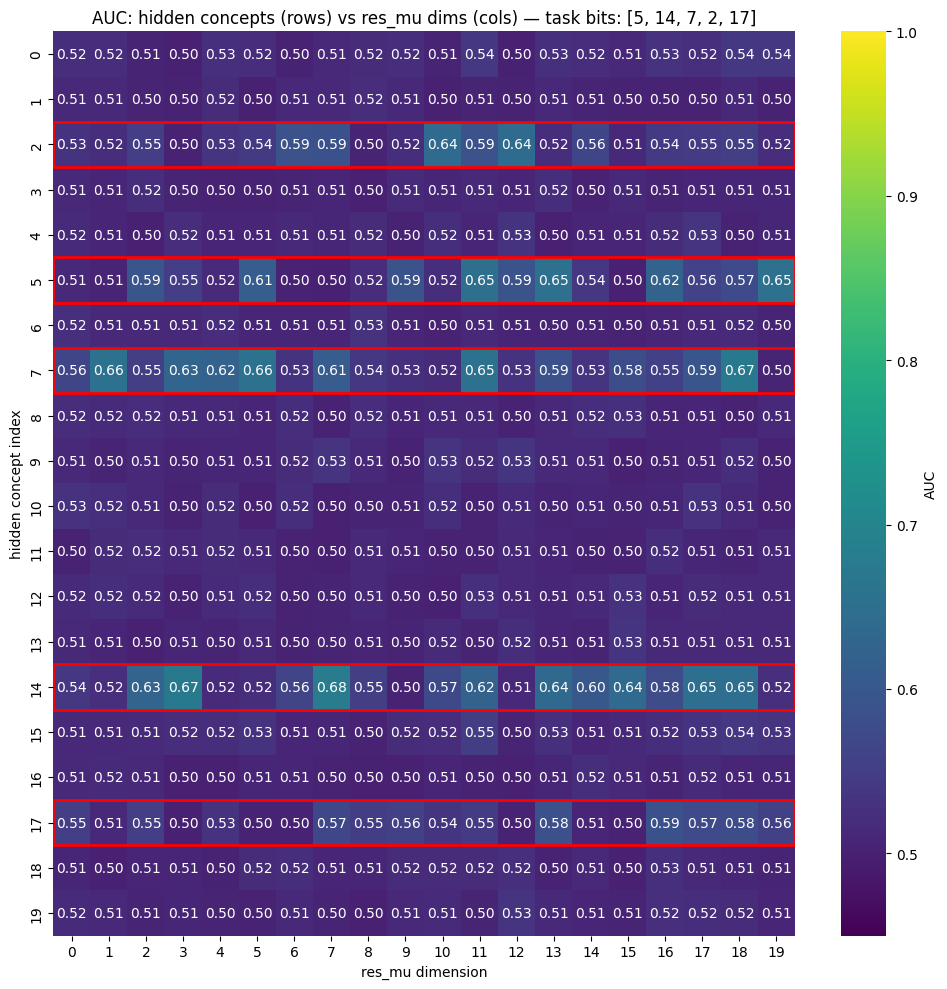

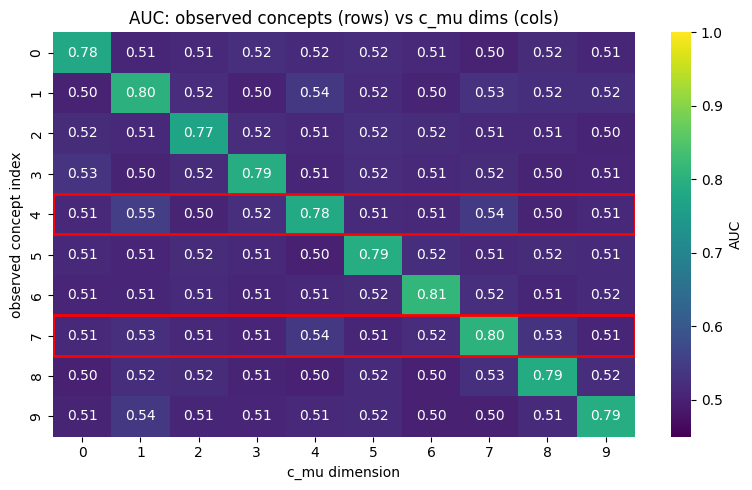

In [89]:
def auc_matrix(true_labels, pred_scores):
    """Compute AUC for every (row, col) pair. Shape: (n_true, n_pred)."""
    n_true = true_labels.shape[1]
    n_pred = pred_scores.shape[1]
    mat = np.zeros((n_true, n_pred))
    for i in range(n_true):
        for j in range(n_pred):
            if len(np.unique(true_labels[:, i])) > 1:
                mat[i, j] = calculate_auc(true_labels[:, i], pred_scores[:, j])
            else:
                mat[i, j] = np.nan
    return mat


def plot_heatmap(mat, title, x_label, y_label, annot=True,
                 highlight_rows=None, highlight_cols=None):
    fig, ax = plt.subplots(figsize=(max(8, mat.shape[1] * 0.5),
                                    max(5, mat.shape[0] * 0.5)))
    sns.heatmap(mat, annot=annot, fmt=".2f", cmap="viridis",
                vmin=0.45, vmax=1.0, ax=ax, cbar_kws={"label": "AUC"})
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if highlight_rows is not None:
        for r in highlight_rows:
            ax.add_patch(plt.Rectangle((0, r), mat.shape[1], 1,
                         fill=False, edgecolor="red", lw=2))
    plt.tight_layout()
    plt.show()


# Hidden concepts vs residual dimensions
auc_mat_hid_res = auc_matrix(
    to_numpy(test_data["hidden_residuals"]),
    to_numpy(test_data["res_mu"]),
)
plot_heatmap(
    auc_mat_hid_res,
    title=f"AUC: hidden concepts (rows) vs res_mu dims (cols) — task bits: {hid_task_idx.tolist()}",
    x_label="res_mu dimension",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)

# Observed concepts vs c_mu (ceiling reference)
auc_mat_obs_cmu = auc_matrix(
    to_numpy(test_data["concepts"]),
    to_numpy(test_data["c_mu"]),
)
plot_heatmap(
    auc_mat_obs_cmu,
    title="AUC: observed concepts (rows) vs c_mu dims (cols)",
    x_label="c_mu dimension",
    y_label="observed concept index",
    highlight_rows=obs_task_idx.tolist(),
    annot=True,
)


## SVD — effective rank of residual channel

With K hidden subtasks the residual channel should collapse to a ~K-dimensional subspace. Check cumulative explained variance: expect ~K significant singular values.

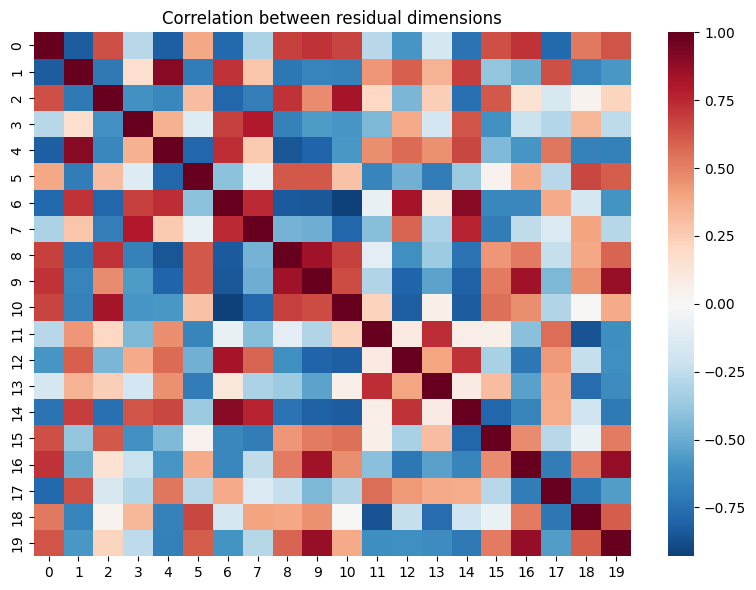

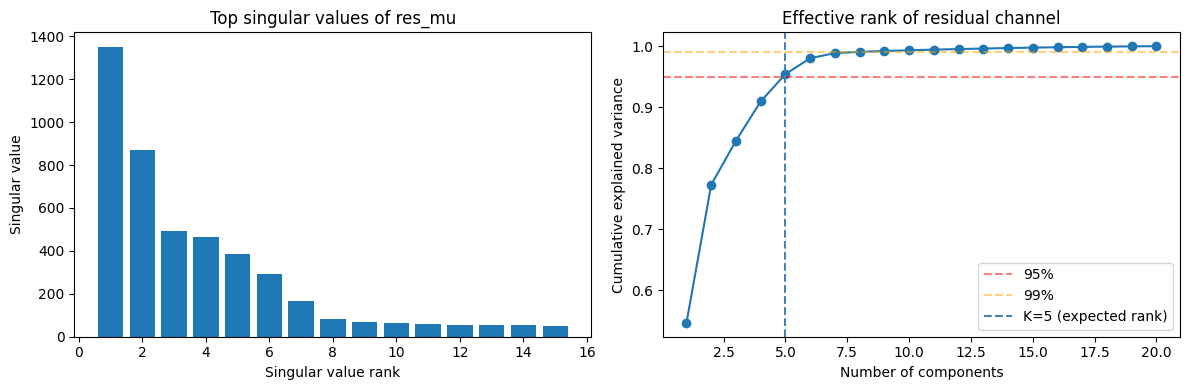

Expected effective rank (num_hid_tasks K): 5
Variance explained by top-K components:    0.9542
Variance explained by top-1:               0.5464
Top singular values: [1351.   869.4  491.6  463.4  387.1  294.6  168.2]


In [90]:
R = to_numpy(test_data["res_mu"])
R_centered = R - R.mean(axis=0)

corr = np.corrcoef(R_centered.T)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, center=0, ax=ax, cmap="RdBu_r")
ax.set_title("Correlation between residual dimensions")
plt.tight_layout()
plt.show()

u, s, vh = np.linalg.svd(R_centered, full_matrices=False)
explained = s**2 / np.sum(s**2)
cumvar    = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, len(s[:15])+1), s[:15])
axes[0].set_xlabel("Singular value rank")
axes[0].set_ylabel("Singular value")
axes[0].set_title("Top singular values of res_mu")

axes[1].plot(np.arange(1, len(cumvar)+1), cumvar, marker="o")
axes[1].axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95%")
axes[1].axhline(0.99, color="orange", linestyle="--", alpha=0.5, label="99%")
# Mark expected effective rank = num_hid_tasks
axes[1].axvline(num_hid_tasks, color="steelblue", linestyle="--",
                label=f"K={num_hid_tasks} (expected rank)")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Effective rank of residual channel")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Expected effective rank (num_hid_tasks K): {num_hid_tasks}")
print(f"Variance explained by top-K components:    {cumvar[num_hid_tasks-1]:.4f}")
print(f"Variance explained by top-1:               {cumvar[0]:.4f}")
print(f"Top singular values: {s[:num_hid_tasks+2].round(1)}")


## PCA alignment — do principal components align with task-bit hidden concepts?

With K subtasks, expect PC1..PCK to each align strongly with one task-bit hidden concept. Non-task-bit concepts should show near-chance AUC with all PCs.

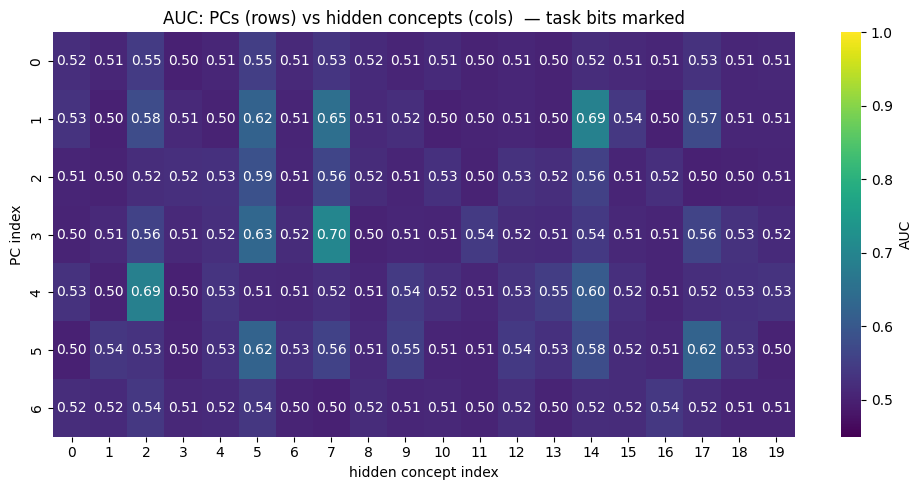

Best hidden concept alignment per PC:


,pc,hidden_concept_idx,auc,explained_variance,is_task_bit
0,1,5,0.550426,0.546415,True
1,2,14,0.689209,0.226278,True
2,3,5,0.585474,0.072341,True
3,4,7,0.702136,0.064305,True
4,5,2,0.686363,0.044868,True
5,6,5,0.623638,0.025982,True
6,7,16,0.538951,0.008475,False


In [91]:
n_pc = min(num_hid_tasks + 2, num_residuals)
pca  = PCA(n_components=n_pc)
Z    = pca.fit_transform(R_centered)   # (n, n_pc)

H    = to_numpy(test_data["hidden_residuals"])

rows = []
for pc_idx in range(n_pc):
    for h_idx in range(H.shape[1]):
        auc = calculate_auc(H[:, h_idx], Z[:, pc_idx])
        rows.append({
            "pc":                pc_idx + 1,
            "hidden_concept_idx": h_idx,
            "auc":               auc,
            "explained_variance": pca.explained_variance_ratio_[pc_idx],
            "is_task_bit":       h_idx in hid_task_idx.tolist(),
        })

pc_df = pd.DataFrame(rows)

# Heatmap: PC (rows) x hidden concept (cols) — AUC
pc_hid_mat = pc_df.pivot(index="pc", columns="hidden_concept_idx", values="auc").values

plot_heatmap(
    pc_hid_mat,
    title="AUC: PCs (rows) vs hidden concepts (cols)  — task bits marked",
    x_label="hidden concept index",
    y_label="PC index",
    highlight_cols=hid_task_idx.tolist(),
    annot=True,
)

# Per-PC: best hidden concept alignment
best_per_pc = pc_df.sort_values("auc", ascending=False).groupby("pc").first().reset_index()
print("Best hidden concept alignment per PC:")
display(best_per_pc[["pc", "hidden_concept_idx", "auc", "explained_variance", "is_task_bit"]])


## Lasso decomposition — which hidden concepts drive each PC?

Fit Lasso(hidden_concept_signals → PC_k) for each of the top K PCs. Coefficients should concentrate on the task-bit hidden concepts.

In [92]:
H_signal = to_numpy(test_data["hidden_residual_signal"])   # (n, hid_dim)

lasso_rows = []
for pc_idx in range(num_hid_tasks):
    pc_vec = Z[:, pc_idx]
    lasso  = make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=10000))
    lasso.fit(H_signal, pc_vec)
    coefs  = lasso.named_steps["lasso"].coef_
    r2     = r2_score(pc_vec, lasso.predict(H_signal))
    for h_idx, coef in enumerate(coefs):
        lasso_rows.append({
            "pc":                pc_idx + 1,
            "hidden_concept_idx": h_idx,
            "coef":              coef,
            "abs_coef":          abs(coef),
            "w_hid":             w_hid[h_idx].item(),
            "abs_w_hid":         w_hid[h_idx].abs().item(),
            "is_task_bit":       h_idx in hid_task_idx.tolist(),
            "r2":                r2,
        })

lasso_df = pd.DataFrame(lasso_rows)

for pc_idx in range(num_hid_tasks):
    sub = lasso_df[lasso_df["pc"] == pc_idx + 1].sort_values("abs_coef", ascending=False)
    r2  = sub["r2"].iloc[0]
    print(f"PC{pc_idx+1}  R²={r2:.3f}  — top coefficients:")
    display(sub[sub["abs_coef"] > 1e-4][
        ["hidden_concept_idx", "coef", "abs_coef", "w_hid", "is_task_bit"]
    ].head(8))
    print()


PC1  R²=0.044  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
5,5,1.390159,1.390159,0.974940,True
2,2,1.215070,1.215070,-0.609588,True
7,7,1.060856,1.060856,0.891934,True
17,17,1.004600,1.004600,0.549488,True
15,15,-0.742895,0.742895,0.000000,False
18,18,-0.707110,0.707110,0.000000,False
14,14,0.677030,0.677030,-0.952066,True
0,0,-0.666757,0.666757,0.000000,False



PC2  R²=0.576  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
34,14,-4.113080,4.113080,-0.952066,True
27,7,3.496470,3.496470,0.891934,True
25,5,2.730513,2.730513,0.974940,True
22,2,-1.695929,1.695929,-0.609588,True
37,17,1.503534,1.503534,0.549488,True
35,15,-0.769800,0.769800,0.000000,False
20,0,-0.605366,0.605366,0.000000,False
23,3,-0.421541,0.421541,0.000000,False



PC3  R²=0.093  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
45,5,-0.869895,0.869895,0.974940,True
47,7,0.744722,0.744722,0.891934,True
54,14,-0.598406,0.598406,-0.952066,True
44,4,0.299232,0.299232,0.000000,False
52,12,-0.292993,0.292993,0.000000,False
42,2,0.279086,0.279086,-0.609588,True
53,13,-0.261817,0.261817,0.000000,False
50,10,-0.248811,0.248811,0.000000,False



PC4  R²=0.472  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
67,7,2.390241,2.390241,0.891934,True
65,5,-1.628732,1.628732,0.974940,True
77,17,-0.743971,0.743971,0.549488,True
62,2,-0.545458,0.545458,-0.609588,True
74,14,0.525995,0.525995,-0.952066,True
71,11,-0.451406,0.451406,0.000000,False
78,18,0.343777,0.343777,0.000000,False
66,6,0.267855,0.267855,0.000000,False



PC5  R²=0.387  — top coefficients:


,hidden_concept_idx,coef,abs_coef,w_hid,is_task_bit
82,2,1.920886,1.920886,-0.609588,True
94,14,-1.034638,1.034638,-0.952066,True
93,13,0.392172,0.392172,0.000000,False
89,9,-0.391297,0.391297,0.000000,False
99,19,-0.346766,0.346766,0.000000,False
92,12,0.345002,0.345002,0.000000,False
97,17,-0.302824,0.302824,0.549488,True
84,4,0.268654,0.268654,0.000000,False


## Per-task score alignment — do PC_k align with s_hid_k?

s_hid[:, k] is the continuous score that determines task k's label. The residual channel should organise so that some direction correlates strongly with each s_hid_k.

Correlation between top PCs and per-task hidden scores (s_hid_k):


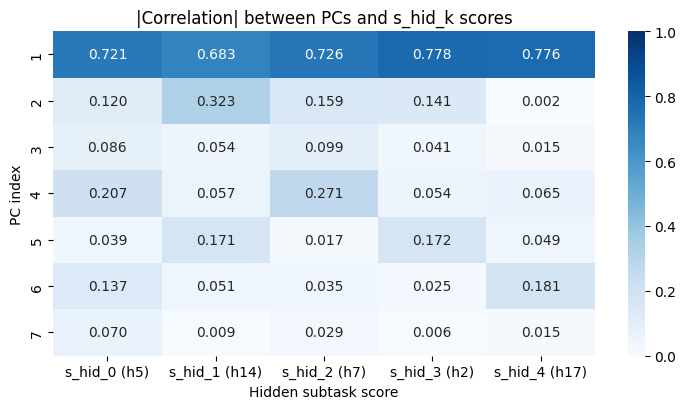


AUC between top PCs and binary task labels:


task,0,1,2,3,4,5,6
pc,,,,,,,
1,0.849,0.830,0.852,0.876,0.877,0.642,0.637
2,0.561,0.643,0.573,0.567,0.503,0.797,0.815
3,0.543,0.525,0.559,0.529,0.508,0.601,0.584
4,0.593,0.534,0.627,0.522,0.528,0.530,0.527
5,0.513,0.574,0.522,0.592,0.508,0.527,0.508
6,0.563,0.533,0.523,0.502,0.577,0.521,0.506
7,0.515,0.525,0.506,0.531,0.519,0.512,0.508


In [93]:
s_hid_np = to_numpy(test_data["s_hid"])   # (n, K)

print("Correlation between top PCs and per-task hidden scores (s_hid_k):")
corr_rows = []
for pc_idx in range(n_pc):
    for k in range(num_hid_tasks):
        corr = np.corrcoef(Z[:, pc_idx], s_hid_np[:, k])[0, 1]
        corr_rows.append({"pc": pc_idx + 1, "hid_task_k": k, "correlation": corr,
                          "hid_concept": hid_task_idx[k].item()})
corr_df = pd.DataFrame(corr_rows)
corr_mat = corr_df.pivot(index="pc", columns="hid_task_k", values="correlation")
corr_mat.columns = [f"s_hid_{k} (h{hid_task_idx[k].item()})" for k in corr_mat.columns]

fig, ax = plt.subplots(figsize=(max(5, num_hid_tasks * 1.5), max(4, n_pc * 0.6)))
sns.heatmap(corr_mat.abs(), annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, ax=ax)
ax.set_title("|Correlation| between PCs and s_hid_k scores")
ax.set_xlabel("Hidden subtask score")
ax.set_ylabel("PC index")
plt.tight_layout()
plt.show()

# Also check correlation with y columns (binary labels)
y_np = to_numpy(test_data["y"])   # (n, K+J)
print("\nAUC between top PCs and binary task labels:")
auc_rows = []
for pc_idx in range(n_pc):
    for t in range(num_tasks):
        label = "hid" if t < num_hid_tasks else "obs"
        auc = calculate_auc(y_np[:, t], Z[:, pc_idx])
        auc_rows.append({"pc": pc_idx + 1, "task": t, "label_type": label, "auc": auc})
auc_task_df = pd.DataFrame(auc_rows)
display(auc_task_df.pivot(index="pc", columns="task", values="auc").round(3))


## Concept channel — does c_mu align with observed subtask scores?

The observed subtask (J tasks) should be recoverable from c_mu. This mirrors the hidden task analysis but for the concept encoder.

In [94]:
s_obs_np = to_numpy(test_data["s_obs"])   # (n, J)
C_mu     = to_numpy(test_data["c_mu"])

pca_c = PCA(n_components=min(num_obs_tasks + 2, num_concepts))
Z_c   = pca_c.fit_transform(C_mu - C_mu.mean(0))

print("Correlation between top concept PCs and s_obs_j scores:")
obs_corr_rows = []
for pc_idx in range(Z_c.shape[1]):
    for j in range(num_obs_tasks):
        corr = np.corrcoef(Z_c[:, pc_idx], s_obs_np[:, j])[0, 1]
        obs_corr_rows.append({
            "pc": pc_idx + 1,
            "obs_task_j": j,
            "correlation": corr,
            "obs_concept": obs_task_idx[j].item(),
        })
obs_corr_df = pd.DataFrame(obs_corr_rows)
obs_corr_mat = obs_corr_df.pivot(index="pc", columns="obs_task_j", values="correlation")
obs_corr_mat.columns = [f"s_obs_{j} (c{obs_task_idx[j].item()})" for j in obs_corr_mat.columns]
display(obs_corr_mat.abs().round(3))


Correlation between top concept PCs and s_obs_j scores:


,s_obs_0 (c4),s_obs_1 (c7)
pc,,
1,0.089,0.299
2,0.161,0.099
3,0.119,0.056
4,0.054,0.058
